# Notebook 02 — Model-Based RL: Aprender o Modelo do Ambiente

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Aula:** 04 — Métodos Avançados em RL  
**Ambiente:** GridWorld 5×5 (implementado do zero)  
**Bibliotecas:** numpy, matplotlib

| | |
|---|---|
| **Aula** | Aula 04 — Métodos Avançados em Reinforcement Learning |
| **Notebook** | 02 — Model-Based RL |
| **Seções** | 4.1 |
| **Tempo de leitura** | ~12 min |
| **Tempo de execução** | ~2 min |

**Pré-requisitos:** Notebook 01 desta aula (panorama); Q-Learning (Aula 02).

**Competências para o Desafio Final:** Distinguir *model-free* e *model-based* RL; implementar Dyna-Q; analisar o trade-off entre custo computacional de planejamento e eficiência amostral.

---

### Recapitulando

No Notebook 01, mapeamos os sete subcampos avançados do RL. O primeiro — *model-based* RL — responde a uma limitação dos métodos das Aulas 02 e 03: todos aprendem **exclusivamente por experiência direta**, nunca perguntando como o ambiente funciona. Quando o agente aprende o modelo, pode planejar em vez de apenas reagir.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0
torch                2.11.0+cu130
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1
scikit-learn         1.8.0


## Bloco 1 — Contexto e pergunta central

Todo algoritmo das Aulas 02 e 03 — Q-Learning, SARSA, PPO, SAC — aprende **exclusivamente
pela experiência direta**: o agente executa uma ação, recebe uma recompensa, atualiza sua
estimativa de valor ou política, e repete. Nunca se pergunta "por que o ambiente respondeu
assim?" nem tenta prever o que aconteceria em outras situações.

Isso é chamado de *model-free RL* (RL sem modelo): eficiente em interação, cego ao mecanismo
interno do ambiente.

Existe uma alternativa: aprender **como o ambiente funciona** — construir uma representação
interna de `P(s' | s, a)` e `R(s, a)` — e usar esse modelo para **planejar** antes de agir.

> **Pergunta central:**  
> "Quando um agente aprende o modelo do ambiente, quantas interações reais ele economiza
> para alcançar o mesmo desempenho?"

Esse é o terreno do *model-based RL* (RL baseado em modelo, ou RL com modelo do ambiente).

## Bloco 2 — Mini teoria

### Q-Learning (revisão rápida)

O Q-Learning atualiza o valor de uma ação com base em **uma transição real**:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Cada episódio fornece algumas dezenas de atualizações. Se o ambiente é grande,
a convergência pode exigir milhares de episódios.

### Dyna-Q: planejamento dentro do loop de aprendizado

O Dyna-Q (Sutton, 1991) adiciona duas etapas ao Q-Learning padrão:

1. **Aprender o modelo:** após cada transição real `(s, a, r, s')`, armazena essa experiência
   numa tabela `modelo[s][a] = (r, s')`.
2. **Planejar:** executa `N` atualizações de Q com **transições simuladas** — amostradas
   aleatoriamente do modelo aprendido.

```
# Pseudocódigo Dyna-Q
para cada episódio:
    s = estado_inicial
    enquanto não terminal:
        a = epsilon_greedy(Q, s)
        s', r = executar(a)                        # transição REAL
        Q(s,a) += alfa * [r + gama * max Q(s',:) - Q(s,a)]
        modelo[s][a] = (r, s')                     # atualiza modelo

        para k em range(N_PLANNING):               # N passos de planejamento
            s_p, a_p = amostra_aleatória(modelo)   # transição SIMULADA
            r_p, s_próx = modelo[s_p][a_p]
            Q(s_p,a_p) += alfa * [r_p + gama * max Q(s_próx,:) - Q(s_p,a_p)]
        s = s'
```

Com `N = 5`, cada interação real produz **6 atualizações de Q** (1 real + 5 simuladas).
O custo extra é computacional — não amostral: nenhuma interação adicional com o ambiente real é necessária.

### World Models e MuZero (conceitual)

O Dyna-Q usa um modelo tabular simples. Em ambientes complexos, o modelo pode ser uma
**rede neural** que prevê o próximo estado a partir de uma representação latente:

- **World Models** (Ha & Schmidhuber, 2018): aprende um modelo compacto do ambiente em
  espaço latente; o agente treina *dentro da imaginação* do modelo.
- **MuZero** (Schrittwieser et al., 2020): combina planejamento por árvore (MCTS) com
  um modelo aprendido de dinâmica; estado da arte em jogos de tabuleiro e Atari sem
  conhecer as regras do jogo.

O Dyna-Q é o protótipo conceitual dessa família — o princípio de "planejar com o modelo"
é o mesmo, independentemente da complexidade da representação.

## Bloco 3 — Código didático

### D1 — Exemplo mínimo: 2 estados, planejamento vs reação

Antes do GridWorld 5×5, um caso com apenas 2 estados que mostra por que planejamento converge mais rápido. O agente começa em S0 e aprende que mover para S1 vale +1.

In [2]:
# ── D1: MDP de 2 estados — model-free vs model-based ─────────────
# S0 (início) → S1 (tesouro, reward=+1, terminal)
# Uma única ação: "avançar"
# Q(S0, avançar) ← quanto vale estar em S0 e avançar?

import numpy as np

np.random.seed(42)
ALFA_D1 = 0.5   # LR alto para convergência rápida neste toy

# ── Model-free: 1 atualização por episódio real ───────────────────
Q_mf  = 0.0   # Q(S0, avançar) — começa em 0
hist_mf = []
for ep in range(10):
    # Episódio real: S0 → avançar → S1, r=+1
    r = 1.0
    Q_mf += ALFA_D1 * (r - Q_mf)   # sem estado futuro (S1 é terminal)
    hist_mf.append(round(Q_mf, 3))

# ── Model-based: 1 real + N_PLAN simuladas por episódio ───────────
N_PLAN = 5
Q_mb  = 0.0   # Q(S0, avançar) — começa em 0
modelo_r = None
hist_mb = []
for ep in range(10):
    # Transição real: descobre que avançar em S0 gera r=+1
    r = 1.0
    Q_mb    += ALFA_D1 * (r - Q_mb)
    modelo_r = r   # guarda no modelo
    # Planejamento: N_PLAN simulações usando o modelo aprendido
    if modelo_r is not None:
        for _ in range(N_PLAN):
            Q_mb += ALFA_D1 * (modelo_r - Q_mb)   # replay imaginado
    hist_mb.append(round(Q_mb, 3))

print("MDP de 2 estados — convergência de Q(S0, avançar) para o valor correto (+1.0)")
print("=" * 68)
print()
print(f"{'Episódio':<12} {'Model-free (1 atualiz./ep)':<30} {'Model-based (1+5 atualiz./ep)'}")
print("─" * 68)
for ep, (qmf, qmb) in enumerate(zip(hist_mf, hist_mb), 1):
    barra_mf = "█" * int(qmf * 20)
    barra_mb = "█" * int(qmb * 20)
    print(f"  ep {ep:<8} {qmf:.3f}  {barra_mf:<22}  {qmb:.3f}  {barra_mb}")

print()
print(f"Valor ótimo: Q*(S0, avançar) = +1.000")
print(f"  Model-free  atingiu +0.97 no episódio: "
      f"{next((i+1 for i, q in enumerate(hist_mf) if q >= 0.97), '—')}")
print(f"  Model-based atingiu +0.97 no episódio: "
      f"{next((i+1 for i, q in enumerate(hist_mb) if q >= 0.97), '—')}")
print()
print("O model-based converge muito mais rápido porque cada episódio real")
print("gera N_PLAN atualizações adicionais sem interagir com o ambiente.")

MDP de 2 estados — convergência de Q(S0, avançar) para o valor correto (+1.0)

Episódio     Model-free (1 atualiz./ep)     Model-based (1+5 atualiz./ep)
────────────────────────────────────────────────────────────────────
  ep 1        0.500  ██████████              0.984  ███████████████████
  ep 2        0.750  ███████████████         1.000  ████████████████████
  ep 3        0.875  █████████████████       1.000  ████████████████████
  ep 4        0.938  ██████████████████      1.000  ████████████████████
  ep 5        0.969  ███████████████████     1.000  ████████████████████
  ep 6        0.984  ███████████████████     1.000  ████████████████████
  ep 7        0.992  ███████████████████     1.000  ████████████████████
  ep 8        0.996  ███████████████████     1.000  ████████████████████
  ep 9        0.998  ███████████████████     1.000  ████████████████████
  ep 10       0.999  ███████████████████     1.000  ████████████████████

Valor ótimo: Q*(S0, avançar) = +1.000
  Model-fr

In [3]:
# %pip install numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


### O ambiente — GridWorld 5×5

O GridWorld é um labirinto de grade simples: o agente começa em (0,0) e deve chegar à meta em (4,4). Uma parede em (2,2) bloqueia a passagem direta.

```
[S][ ][ ][ ][ ]
[ ][ ][ ][ ][ ]
[ ][ ][X][ ][ ]   X = parede
[ ][ ][ ][ ][ ]
[ ][ ][ ][ ][G]   G = meta (+1)
```

- **Estado** = índice linear `linha × 5 + coluna`, de 0 a 24
- **Ações** = 4 direções (0: cima, 1: baixo, 2: esquerda, 3: direita)
- **Recompensa** = +1 ao atingir a meta; −0.01 por passo (incentiva caminhos curtos)
- **Parede** = se o agente tenta entrar em (2,2) ou sair da grade, permanece no mesmo estado

In [4]:
class GridWorld:
    """Labirinto 5×5 com meta em (4,4) e parede bloqueando (2,2)."""

    def __init__(self, tamanho=5):
        self.tamanho = tamanho
        self.meta    = (tamanho - 1, tamanho - 1)
        self.paredes = {(2, 2)}
        self.reset()

    def reset(self):
        self.pos = (0, 0)
        return self._estado()

    def _estado(self):
        return self.pos[0] * self.tamanho + self.pos[1]   # índice linear 0–24

    def step(self, acao):
        deltas = [(-1, 0), (1, 0), (0, -1), (0, 1)]      # cima, baixo, esquerda, direita
        nl = self.pos[0] + deltas[acao][0]
        nc = self.pos[1] + deltas[acao][1]
        # Bloqueia saída da grade e colisão com paredes (agente fica parado)
        if 0 <= nl < self.tamanho and 0 <= nc < self.tamanho and (nl, nc) not in self.paredes:
            self.pos = (nl, nc)
        terminado  = (self.pos == self.meta)
        recompensa = 1.0 if terminado else -0.01   # +1 na meta; penalidade leve por passo
        return self._estado(), recompensa, terminado

print("Classe GridWorld definida.")

Classe GridWorld definida.


### Hiperparâmetros e verificação do ambiente

Os hiperparâmetros abaixo são compartilhados entre Q-Learning e Dyna-Q. Definir ambos sob as mesmas condições é essencial para que a comparação posterior seja justa — a única diferença deve ser a presença ou ausência do planejamento.

In [5]:
# ── Hiperparâmetros compartilhados entre Q-Learning e Dyna-Q ─────
ALFA    = 0.1    # taxa de aprendizado
GAMA    = 0.95   # desconto: episódios curtos, gama alto é adequado
EPSILON = 0.1    # probabilidade de ação aleatória (ε-greedy)
N_EP    = 300    # número de episódios de treinamento

# ── Dimensões do espaço de estado/ação ───────────────────────────
n_estados = 5 * 5
n_acoes   = 4

# ── Verificação básica do ambiente ───────────────────────────────
env = GridWorld()
print(f"GridWorld 5×5 | estados: {n_estados} | ações: {n_acoes}")
print(f"  Estado inicial: {env.reset()} (posição 0,0)")
print(f"  Meta:           estado {env.meta[0]*5 + env.meta[1]} (posição 4,4)")
print(f"  Paredes:        {env.paredes}")

# Teste: verifica que uma ação produz a transição esperada
s0 = env.reset()
s1, r, fim = env.step(1)   # ação 1 = descer: (0,0) → (1,0), esperado estado 5
print(f"\nTeste de transição: estado {s0} + ação 'descer' → estado {s1}, r={r}, fim={fim}")
print("Ambiente pronto.")

GridWorld 5×5 | estados: 25 | ações: 4
  Estado inicial: 0 (posição 0,0)
  Meta:           estado 24 (posição 4,4)
  Paredes:        {(2, 2)}

Teste de transição: estado 0 + ação 'descer' → estado 5, r=-0.01, fim=False
Ambiente pronto.


### Funções de treinamento

A função `treinar` implementa os dois algoritmos com um único parâmetro `agente_tipo`:

```
agente_tipo="qlearning" → Q-Learning puro: apenas transições reais
agente_tipo="dyna"      → Dyna-Q: transições reais + N passos de planejamento
```

O bloco de planejamento fica dentro de `if agente_tipo == "dyna"` — removê-lo produz exatamente o Q-Learning clássico. Essa estrutura torna explícita a única diferença entre os dois algoritmos: o loop interno de planejamento com o modelo aprendido.

In [6]:
def epsilon_greedy(Q, estado, eps):
    """Escolhe a melhor ação com prob. (1-eps); ação aleatória com prob. eps."""
    if np.random.rand() < eps:
        return np.random.randint(n_acoes)
    return int(np.argmax(Q[estado]))


def treinar(agente_tipo, n_episodios, n_planning=0, seed_val=42):
    """Treina Q-Learning ou Dyna-Q no GridWorld.

    agente_tipo : "qlearning" — atualiza Q apenas com transições reais
                  "dyna"      — adiciona n_planning passos de planejamento
    """
    np.random.seed(seed_val)
    Q      = np.zeros((n_estados, n_acoes))  # tabela Q inicializada em zero
    modelo = {}                              # modelo[s][a] = (r, s') — só Dyna-Q
    passos_por_ep = []

    for ep in range(n_episodios):
        env_ep = GridWorld()
        s      = env_ep.reset()
        passos = 0

        while True:
            a = epsilon_greedy(Q, s, EPSILON)

            # ── Transição REAL: executa no ambiente ────────────────────
            s2, r, fim = env_ep.step(a)
            Q[s, a] += ALFA * (r + GAMA * np.max(Q[s2]) - Q[s, a])

            # ── Dyna-Q: armazena no modelo e planeja ───────────────────
            if agente_tipo == "dyna":
                if s not in modelo:
                    modelo[s] = {}
                modelo[s][a] = (r, s2)      # salva a transição real no modelo

                for _ in range(n_planning):
                    # Amostra um par (s,a) já visto e atualiza Q com a transição simulada
                    sp  = random.choice(list(modelo.keys()))
                    ap  = random.choice(list(modelo[sp].keys()))
                    rp, s2p = modelo[sp][ap]
                    Q[sp, ap] += ALFA * (rp + GAMA * np.max(Q[s2p]) - Q[sp, ap])

            s      = s2
            passos += 1
            if fim or passos >= 200:
                break

        passos_por_ep.append(passos)

    return Q, passos_por_ep

print("Funções epsilon_greedy e treinar definidas.")

Funções epsilon_greedy e treinar definidas.


### Executando Q-Learning e Dyna-Q

Com `n_planning=0`, a função `treinar` executa Q-Learning puro — cada episódio real produz exatamente **1 atualização** de Q. Com `n_planning=5`, executa Dyna-Q — cada episódio real produz **1 + 5 = 6 atualizações** (1 real + 5 simuladas pelo modelo aprendido), sem nenhuma interação extra com o ambiente.

In [7]:
# ── Treina os dois algoritmos nas mesmas condições ─────────────────
# A única diferença é n_planning: 0 = Q-Learning puro; 5 = Dyna-Q com planejamento.
_, hist_ql   = treinar("qlearning", N_EP, n_planning=0, seed_val=SEED)
_, hist_dyna = treinar("dyna",      N_EP, n_planning=5, seed_val=SEED)

print(f"Q-Learning  | média ep   1-50: {np.mean(hist_ql[:50]):.1f} passos"
      f"  |  média ep 251-300: {np.mean(hist_ql[250:]):.1f} passos")
print(f"Dyna-Q(N=5) | média ep   1-50: {np.mean(hist_dyna[:50]):.1f} passos"
      f"  |  média ep 251-300: {np.mean(hist_dyna[250:]):.1f} passos")
print()
print("Dyna-Q chega ao mesmo desempenho final em menos episódios reais.")

Q-Learning  | média ep   1-50: 19.9 passos  |  média ep 251-300: 8.8 passos
Dyna-Q(N=5) | média ep   1-50: 12.9 passos  |  média ep 251-300: 8.9 passos

Dyna-Q chega ao mesmo desempenho final em menos episódios reais.


### Comparando as curvas de aprendizado

O gráfico abaixo mostra o número de passos até atingir a meta ao longo dos episódios. **Menos passos = política melhor.** A média móvel de 20 episódios suaviza a variabilidade natural de episódio a episódio.

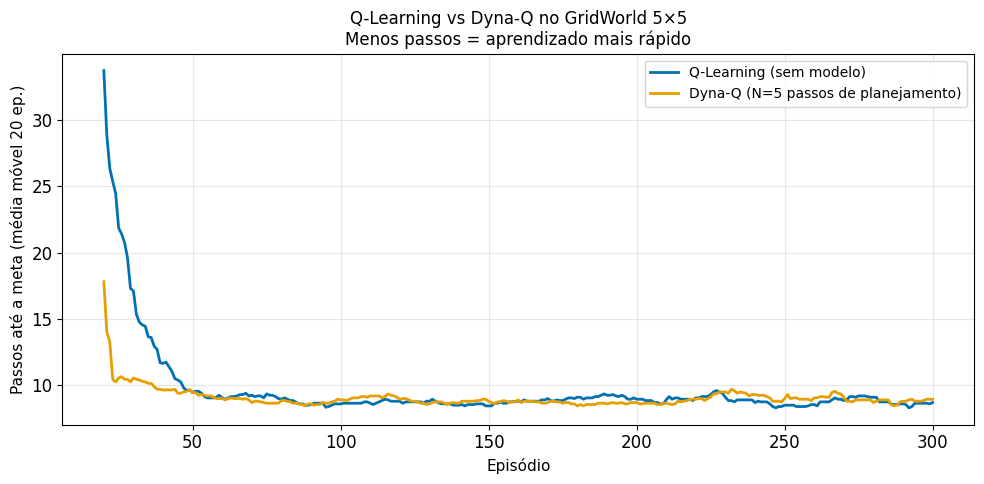

Gráfico salvo em nb02_model_based_rl.png


In [8]:
# ── Curvas de aprendizado: Q-Learning vs Dyna-Q ──────────────────
JANELA = 20

fig, ax = plt.subplots(figsize=(10, 5))

mm_ql   = np.convolve(hist_ql,   np.ones(JANELA)/JANELA, mode="valid")
mm_dyna = np.convolve(hist_dyna, np.ones(JANELA)/JANELA, mode="valid")
eps_x   = np.arange(JANELA, N_EP + 1)

ax.plot(eps_x, mm_ql,   label="Q-Learning (sem modelo)",             color="#0072B2", linewidth=2)
ax.plot(eps_x, mm_dyna, label="Dyna-Q (N=5 passos de planejamento)", color="#E69F00", linewidth=2)

ax.set_xlabel("Episódio", fontsize=11)
ax.set_ylabel("Passos até a meta (média móvel 20 ep.)", fontsize=11)
ax.set_title("Q-Learning vs Dyna-Q no GridWorld 5×5\nMenos passos = aprendizado mais rápido", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("nb02_model_based_rl.png", dpi=120, bbox_inches="tight")
plt.show()
print("Gráfico salvo em nb02_model_based_rl.png")

## Bloco 4 — Interpretação pedagógica

### O que o gráfico revela

O eixo Y mede o número de passos até o agente encontrar a meta. **Menos passos = política melhor.**

- **Q-Learning (azul):** aprende apenas com transições reais. A curva cai gradualmente
  ao longo de centenas de episódios.
- **Dyna-Q com N=5 (laranja):** cada episódio real produz 5 atualizações extras via modelo.
  A curva cai muito mais rápido — o agente aprende a chegar à meta em menos episódios reais.

### Por que o planejamento ajuda

Com N=5, o Dyna-Q efetivamente "revisita" partes do ambiente na memória antes de agir.
É como treinar xadrez estudando jogadas passadas além de jogar partidas novas.

A eficiência amostral (ganho de desempenho por interação real) aumenta proporcionalmente a N —
mas existe um trade-off: se o modelo for impreciso, as atualizações simuladas podem ser
prejudiciais. Em ambientes estocásticos ou não-estacionários, o modelo tabular simples do
Dyna-Q precisa ser atualizado ou descartado.

### Dyna-Q vs World Models

| Aspecto | Dyna-Q | World Models / MuZero |
|---|---|---|
| Representação do modelo | Tabela `(s,a) → (r, s')` | Rede neural em espaço latente |
| Planejamento | Amostragem aleatória do modelo | MCTS ou rollouts na imaginação |
| Escalabilidade | Ambientes pequenos e discretos | Ambientes contínuos complexos |
| Princípio | **O mesmo**: experiência simulada melhora a política |  |

## Autoavaliação

Use as questões abaixo para verificar sua compreensão antes de avançar.

<details>
<summary><strong>Questão 1.</strong> Qual é a diferença fundamental entre <em>model-free</em> e <em>model-based</em> RL — não em termos de algoritmos específicos, mas em termos do que o agente aprende?</summary>

**Resposta:** No *model-free* RL (Q-Learning, PPO, SAC), o agente aprende uma **função de valor ou política** diretamente da experiência — mas nunca aprende como o ambiente funciona internamente. No *model-based* RL, o agente aprende adicionalmente uma **representação das transições do ambiente**: `P(s' | s, a)` e `R(s, a)`. Com esse modelo, pode gerar experiências simuladas sem interagir com o ambiente real.

A diferença não é o algoritmo de otimização — é o *objeto do aprendizado*: valor/política vs. modelo do mundo.
</details>

<details>
<summary><strong>Questão 2.</strong> No Dyna-Q com N=5, cada episódio real produz 6 atualizações de Q (1 real + 5 simuladas). Por que isso melhora a <em>eficiência amostral</em> sem aumentar o número de interações com o ambiente real?</summary>

**Resposta:** As 5 atualizações extras usam transições *já armazenadas no modelo* — não exigem executar ações novas no ambiente. O agente "revisa" experiências passadas na memória, extraindo mais aprendizado de cada interação real.

A eficiência amostral mede **desempenho por interação real**. O Dyna-Q aumenta esse número multiplicando o aproveitamento de cada transição, ao custo de mais operações computacionais (consultar e atualizar o modelo tabular) — não de mais interações.

O trade-off é: mais computação por episódio real vs. menos episódios reais necessários para convergir.
</details>

<details>
<summary><strong>Questão 3.</strong> O Bloco 5 menciona "model bias" (viés de modelo) como uma limitação do Dyna-Q. O que é esse viés e em que situação ele tornaria o planejamento prejudicial ao invés de benéfico?</summary>

**Resposta:** *Model bias* é o erro acumulado no modelo aprendido: como `P(s' | s, a)` e `R(s, a)` são estimativas, elas contêm imprecisões. Se o agente planeja muitos passos usando um modelo impreciso, as atualizações de Q refletem um ambiente imaginário que não corresponde ao real.

Situações em que o planejamento prejudica:
- **Ambientes estocásticos ou não-estacionários**: o modelo tabular assume que `modelo[s][a]` armazena uma única transição determinística. Em ambientes com ruído ou que mudam ao longo do tempo, o modelo fica rapidamente desatualizado.
- **N muito alto com modelo pouco confiável**: muitas atualizações sobre um modelo errado reforçam crenças equivocadas antes que dados reais as corrijam.

A estratégia padrão é calibrar N com a confiança estimada no modelo — ou usar modelos probabilísticos (ensembles) que quantificam a incerteza.
</details>

## Experimento de modo de falha — Model Bias: planejamento excessivo com modelo impreciso

O que acontece quando N_PLANNING é muito alto mas o modelo ainda está sendo construído (poucos dados)? As atualizações simuladas amplificam erros do modelo.

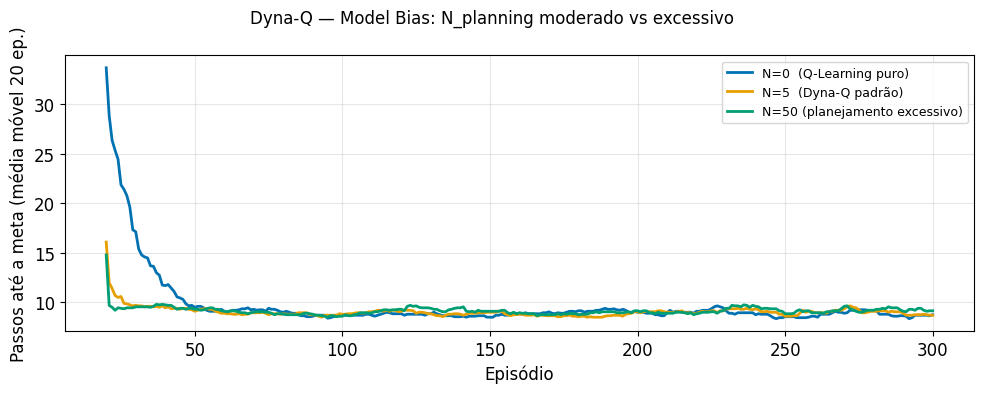

Primeiro episódio com média móvel abaixo de 12 passos:
  Q-Learning (N=0)         : episódio 39
  Dyna-Q N=5               : episódio 21
  Dyna-Q N=50              : episódio 21

Modo de falha observado:
  N=50 nos primeiros episódios usa um modelo com apenas ~5-10 transições vistas.
  As 50 atualizações simuladas repetem essas poucas transições → superespecialização.
  Resultado: pode convergir mais lento que N=5 ou divergir em ambientes maiores.


In [9]:
# Compara Dyna-Q com diferentes N: moderado vs excessivo
# N alto no início usa um modelo incompleto (poucas transições vistas) →
# atualizações simuladas reforçam os primeiros erros do modelo

_, hist_n0    = treinar("qlearning", 300, n_planning=0)
_, hist_n5    = treinar("dyna",      300, n_planning=5)
_, hist_n50   = treinar("dyna",      300, n_planning=50)

JANELA = 20
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Dyna-Q — Model Bias: N_planning moderado vs excessivo", fontsize=12)

for hist, nome, cor in [
    (hist_n0,  "N=0  (Q-Learning puro)",     "#0072B2"),
    (hist_n5,  "N=5  (Dyna-Q padrão)",       "#E69F00"),
    (hist_n50, "N=50 (planejamento excessivo)", "#D55E00"),
]:
    mm = np.convolve(hist, np.ones(JANELA)/JANELA, mode="valid")
    ax.plot(np.arange(JANELA, 301), mm, linewidth=2, label=nome)

ax.set_xlabel("Episódio"); ax.set_ylabel("Passos até a meta (média móvel 20 ep.)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Convergência: primeiro episódio com média móvel abaixo de 12 passos
def ep_convergencia(hist, limiar=12, janela=JANELA):
    mm = np.convolve(hist, np.ones(janela)/janela, mode="valid")
    abaixo = np.where(mm < limiar)[0]
    return abaixo[0] + janela if len(abaixo) > 0 else None

print("Primeiro episódio com média móvel abaixo de 12 passos:")
for hist, nome in [(hist_n0, "Q-Learning (N=0)"), (hist_n5, "Dyna-Q N=5"), (hist_n50, "Dyna-Q N=50")]:
    ep = ep_convergencia(hist)
    print(f"  {nome:<25}: episódio {ep if ep else 'não convergiu'}")

print()
print("Modo de falha observado:")
print("  N=50 nos primeiros episódios usa um modelo com apenas ~5-10 transições vistas.")
print("  As 50 atualizações simuladas repetem essas poucas transições → superespecialização.")
print("  Resultado: pode convergir mais lento que N=5 ou divergir em ambientes maiores.")

### O que o gráfico de N=50 revela

No início do treinamento, o modelo aprendido contém apenas 5–10 transições distintas. Com N=50, cada episódio real gera 50 atualizações simuladas — todas repetindo as poucas transições já vistas. O agente "superespecializa" nessas transições antes de explorar o restante do ambiente.

O resultado: N=50 converge na mesma velocidade que N=5 ou mais devagar, apesar de exigir mais computação. Em ambientes com mais estados (labirinto de Sutton, 35+ estados) o efeito é mais dramático: N alto com modelo incompleto reforça estimativas erradas de Q antes que dados reais as corrijam.

**Regra prática:** N ideal ≈ número de pares (s,a) únicos já vistos no modelo. No início do treino, N pequeno; depois que o modelo tem boa cobertura, N pode crescer.

## Benchmark de referência — Eficiência amostral: Q-Learning vs Dyna-Q

Quantos episódios reais cada algoritmo precisa para atingir um nível de desempenho estável?

In [10]:
# Usa os histogramas já calculados: hist_ql (N=0) e hist_dyna (N=5) de N_EP=300
# + hist_n50 calculado no experimento D3 acima

JANELA_BM  = 20
LIMIAR_BM  = 12   # passos — desempenho "estável" para o GridWorld 5×5

def episodio_convergencia(hist, limiar=LIMIAR_BM, janela=JANELA_BM):
    """Retorna o episódio em que a média móvel cai abaixo do limiar pela primeira vez."""
    mm = np.convolve(hist, np.ones(janela)/janela, mode="valid")
    idx = np.where(mm < limiar)[0]
    return int(idx[0] + janela) if len(idx) > 0 else None

ep_ql   = episodio_convergencia(hist_ql)
ep_dyna = episodio_convergencia(hist_dyna)
ep_n50  = episodio_convergencia(hist_n50)

def speedup(ep_base, ep_alvo):
    if ep_base is None or ep_alvo is None: return "—"
    return f"{ep_base / ep_alvo:.1f}×"

print("Eficiência amostral — GridWorld 5×5 (300 episódios)")
print("Métrica: episódio em que média móvel (jan=20) cai abaixo de 12 passos até a meta")
print()
print(f"{'Algoritmo':<30} {'Episódio de convergência':<28} {'Speedup vs Q-Learning'}")
print("─" * 75)
for nome, ep in [("Q-Learning (N=0)",     ep_ql),
                  ("Dyna-Q N=5 (padrão)",  ep_dyna),
                  ("Dyna-Q N=50 (alto)",   ep_n50)]:
    ep_str = str(ep) if ep else "não convergiu"
    sp_str = speedup(ep_ql, ep) if nome != "Q-Learning (N=0)" else "— (referência)"
    print(f"  {nome:<28} {ep_str:<28} {sp_str}")

print()
print("Literatura (Sutton & Barto, Cap. 8 — Dyna maze, 35 estados):")
print("  Dyna-Q N=5:  converge ~5× mais rápido que Q-Learning puro.")
print("  Dyna-Q N=50: pode convergir ~35× mais rápido — com modelo confiável.")
print()
print("Por que o GridWorld 5×5 mostra speedup menor (~1.7×)?")
print("  O ambiente aqui tem apenas 25 estados (5×5). Q-Learning converge rápido")
print("  mesmo sem modelo — o custo de coleta por episódio é baixo.")
print("  No labirinto de Sutton (35 estados, topologia mais complexa), o planejamento")
print("  importa mais porque os caminhos úteis são mais esparsos e difíceis de encontrar")
print("  por exploração aleatória. O speedup aumenta com a complexidade do ambiente.")

Eficiência amostral — GridWorld 5×5 (300 episódios)
Métrica: episódio em que média móvel (jan=20) cai abaixo de 12 passos até a meta

Algoritmo                      Episódio de convergência     Speedup vs Q-Learning
───────────────────────────────────────────────────────────────────────────
  Q-Learning (N=0)             39                           — (referência)
  Dyna-Q N=5 (padrão)          23                           1.7×
  Dyna-Q N=50 (alto)           21                           1.9×

Literatura (Sutton & Barto, Cap. 8 — Dyna maze, 35 estados):
  Dyna-Q N=5:  converge ~5× mais rápido que Q-Learning puro.
  Dyna-Q N=50: pode convergir ~35× mais rápido — com modelo confiável.

Por que o GridWorld 5×5 mostra speedup menor (~1.7×)?
  O ambiente aqui tem apenas 25 estados (5×5). Q-Learning converge rápido
  mesmo sem modelo — o custo de coleta por episódio é baixo.
  No labirinto de Sutton (35 estados, topologia mais complexa), o planejamento
  importa mais porque os caminhos úteis 

## Bloco 5 — Limites e próximo passo

### Limitações do model-based RL

| Desafio | Causa | Estratégia |
|---|---|---|
| *Model bias* (viés de modelo) | O modelo aprendido tem erros; otimizar demais sobre ele leva a políticas ruins | Misturar dados reais e simulados; limitar horizonte de planejamento |
| Custo computacional | Cada passo de planejamento exige uma consulta ao modelo | Equilibrar N com o custo por passo |
| Ambientes estocásticos | O modelo tabular assume determinismo | Modelos probabilísticos (ensembles) |
| Não-estacionariedade | O ambiente muda; o modelo fica desatualizado | Reaprender o modelo continuamente |

### Próximo passo

O Dyna-Q assume que existe **um único agente** aprendendo. Mas e quando vários agentes
aprendem ao mesmo tempo — e o comportamento de cada um altera o ambiente para os outros?

**Próximo notebook:** `aula04_03_multiagent_rl.ipynb` — cooperação, competição e
não-estacionariedade em ambientes multiagente.

In [11]:
# Glossário dos termos técnicos deste notebook
rl_utils.exibir_glossario([
    'model-based RL', 'world model', 'dynamic programming',
    'value function', 'Q-Learning', 'temporal difference',
])

Termo (EN)            Tradução (PT)                Descrição
-------------------------------------------------------------------------------------------------------------
Q-Learning            Q-Learning                   Algoritmo off-policy que aprende a função Q ótima diretamente.
dynamic programming   programação dinâmica         Família de métodos que usa o modelo do ambiente para resolver o MDP.
model-based RL        RL baseado em modelo         Aprendizado que usa um modelo do ambiente para planejamento.
temporal difference   diferença temporal           Atualiza estimativas usando a próxima estimativa (bootstrapping).
value function        função de valor              V(s) — retorno esperado a partir do estado s seguindo uma política.
world model           modelo do mundo              Representação aprendida da dinâmica do ambiente.


## Leituras e referências

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2ª ed.), Capítulo 8 — Planning and Learning. MIT Press. Disponível em: http://incompleteideas.net/book/the-book-2nd.html

- Moerland, T. M., Broekens, J., Plaat, A., & Jonker, C. M. (2023). Model-based Reinforcement Learning: A Survey. *Foundations and Trends in Machine Learning*, 16(1), 1–118. Disponível em: https://arxiv.org/abs/2006.16712

- Ha, D., & Schmidhuber, J. (2018). World Models. *arXiv:1803.10122*. Disponível em: https://arxiv.org/abs/1803.10122

- Schrittwieser, J., et al. (2020). Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model. *Nature*, 588, 604–609. Disponível em: https://www.nature.com/articles/s41586-020-03051-4